### Load necesary Libraries

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# import plotly.express as px

%matplotlib inline

### Load Dataset

In [15]:
df = pd.read_csv("quick_commerce_data_raw.csv")
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [17]:
# Summary statistics of the dataset
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [18]:
# Cheking for missing values
df.isnull().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [19]:
df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


### Remove Rows having Null Values

In [20]:
# Droping rows with missing values in "City" column
df = df.dropna(subset=["City"])

In [21]:
df.shape

(948000, 13)

In [22]:
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [24]:
# Filling missing values in "Items_Count" column with the mode
df["Items_Count"] = df["Items_Count"].fillna(df["Items_Count"].mode()[0])
df.isnull().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

### Fill Null Values with group-wise Mean/Median

In [27]:
# Use Group-wise mean imputation
df["Customer_Rating"] = df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [28]:
df["Delivery_Partner_Rating"] = df.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].transform(lambda y:y.fillna(y.mean()))
df.isna().sum()


Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [29]:
df["Delivery_Partner_Rating"].fillna(df["Delivery_Partner_Rating"].mean(), inplace=True)
df.isna().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_15468\420677552.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Delivery_Partner_Rating"].fillna(df["Delivery_Partner_Rating"].mean(), inplace=True)


Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64

### Remove Outliers

<Axes: >

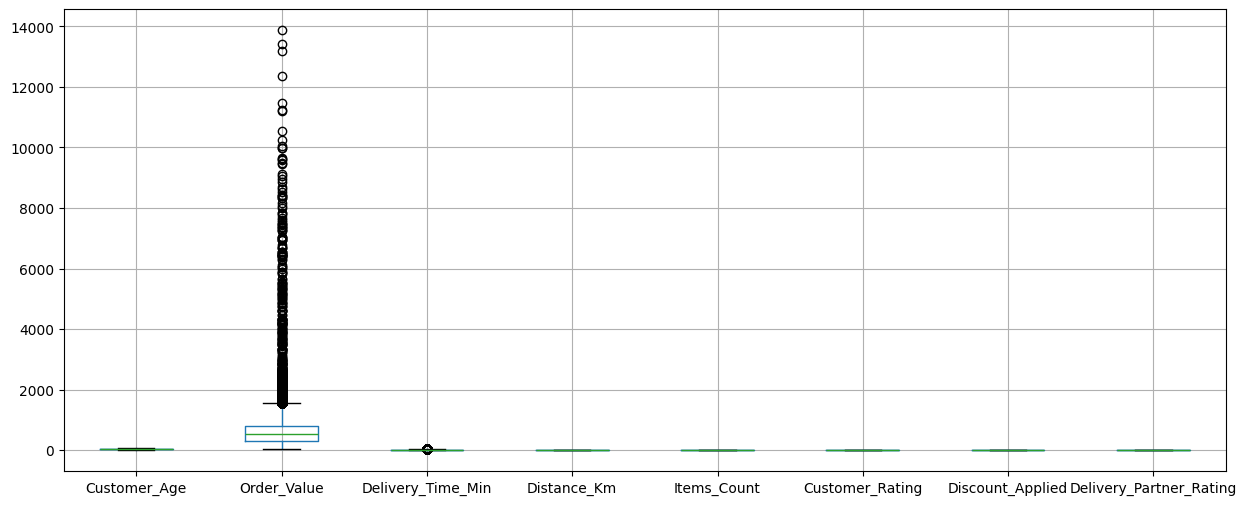

In [32]:
# Box plot
plt.figure(figsize=(15,6))
df.drop(columns=["Order_ID"]).boxplot()

In [34]:
# df["Order_Value"] = df["Order_Value"].clip(upper=2500)

# 2) Filtering
df = df[df["Order_Value"] <=2500 ]

<Axes: >

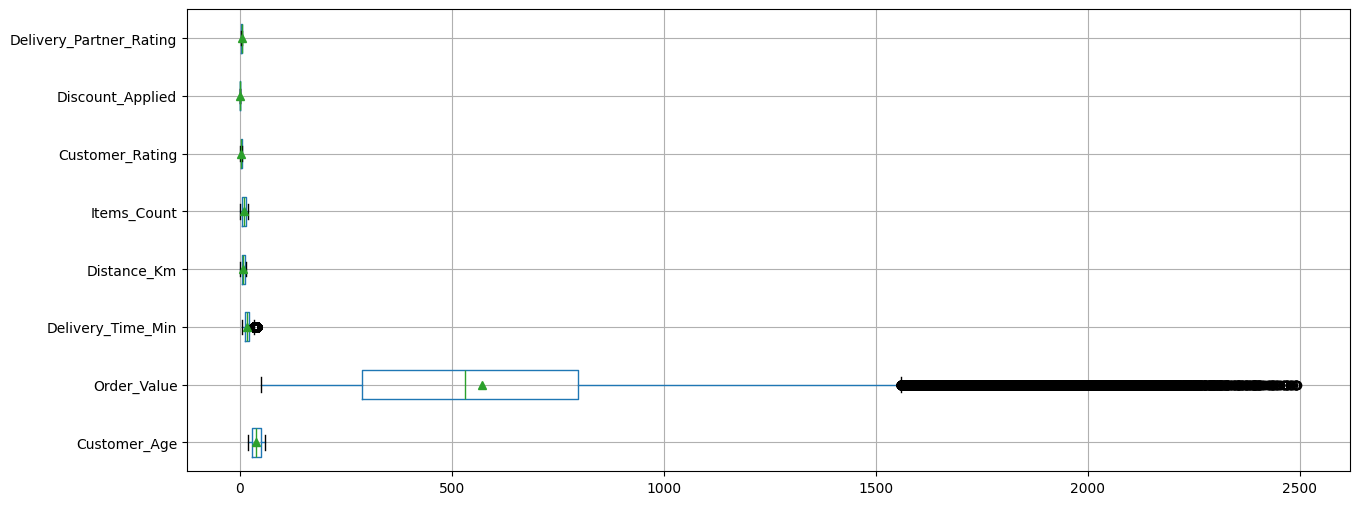

In [37]:
plt.figure(figsize=(15,6))
df.drop(columns=["Order_ID"]).boxplot(vert=False,showmeans=True)

In [38]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912385,16.502070,7.750046,10.313292,3.042843,0.400786,3.749173
std,2.887273e+05,12.118982,374.174789,6.330106,4.186990,5.630770,1.161112,0.490058,0.684365
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249939e+06,28.000000,287.923000,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.674100,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750145e+06,49.000000,796.556650,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2492.435250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947752 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.2+ MB
